# 실습 2-2 : 로지스틱 회귀

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 구조적 정보 / 통계적 정보
- 범주형 변수 처리 (One-Hot Encoding)
- 입출력 변수 분할
- 학습/테스트 데이터 분할
- 스케일링

2. 로지스틱 회귀
- 모델 학습 및 성능 평가
- 회귀 계수 해석

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

### 데이터 불러오기

In [2]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-2_data.csv"))

---

## 1) 데이터 탐색 및 전처리

### 1-1) 구조적 정보

In [3]:
# 앞부분 데이터 확인
MF_Data.head(n=5)

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No


In [4]:
# 데이터 정보 확인
MF_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7900 entries, 0 to 7899
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Temperature                   7900 non-null   int64 
 1   Humidity                      7900 non-null   int64 
 2   Operator                      7900 non-null   object
 3   Measure1                      7900 non-null   int64 
 4   Measure2                      7900 non-null   int64 
 5   Measure3                      7900 non-null   int64 
 6   Measure4                      7900 non-null   int64 
 7   Measure5                      7900 non-null   int64 
 8   Measure6                      7900 non-null   int64 
 9   Measure7                      7900 non-null   int64 
 10  Measure8                      7900 non-null   int64 
 11  Measure9                      7900 non-null   int64 
 12  Measure10                     7900 non-null   int64 
 13  Measure11         

In [5]:
# 데이터 크기 확인
print("데이터 크기 :", MF_Data.shape)

데이터 크기 : (7900, 20)


- 현재 설비 상태(온도, 습도, 센서값, 이전 고장 후 경과시간)를 이용하여 향후 고장(Failure) 발생 여부를 예측하는 이진 분류 데이터셋

### 1-2) 통계적 정보

In [6]:
# 요약 통계량 확인
MF_Data.describe(include="all")

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
count,7900.000000,7900.000000,7900,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900
unique,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Operator2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,1751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7825
mean,64.055949,83.703671,NaN,1093.450380,1.488608,1.002025,1068.763924,1075.140000,1077.938228,1089.496076,1075.945190,1082.146962,1081.997975,1088.974684,1088.998228,1074.699241,1091.435949,1083.851899,210.289241,NaN
std,2.668864,4.806356,NaN,535.438555,1.114985,0.813854,535.724483,533.727253,533.450621,537.130674,537.184388,531.296016,538.075952,534.544434,532.217592,535.322092,536.685002,537.114706,143.875473,NaN
min,60.000000,65.000000,NaN,155.000000,0.000000,0.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,1.000000,NaN
25%,62.000000,80.000000,NaN,633.000000,0.000000,0.000000,605.000000,603.750000,626.000000,625.000000,609.000000,634.000000,618.000000,628.000000,630.000000,605.000000,622.000000,615.750000,89.000000,NaN
50%,64.000000,84.000000,NaN,1098.500000,2.000000,1.000000,1056.000000,1075.000000,1073.000000,1091.000000,1073.000000,1076.000000,1076.500000,1093.000000,1081.000000,1064.500000,1090.500000,1078.000000,192.000000,NaN
75%,66.000000,87.000000,NaN,1556.000000,2.000000,2.000000,1530.000000,1541.250000,1541.250000,1561.000000,1540.000000,1527.250000,1547.000000,1548.000000,1549.500000,1537.000000,1564.250000,1552.000000,314.000000,NaN


### 1-3) 시각적 탐색

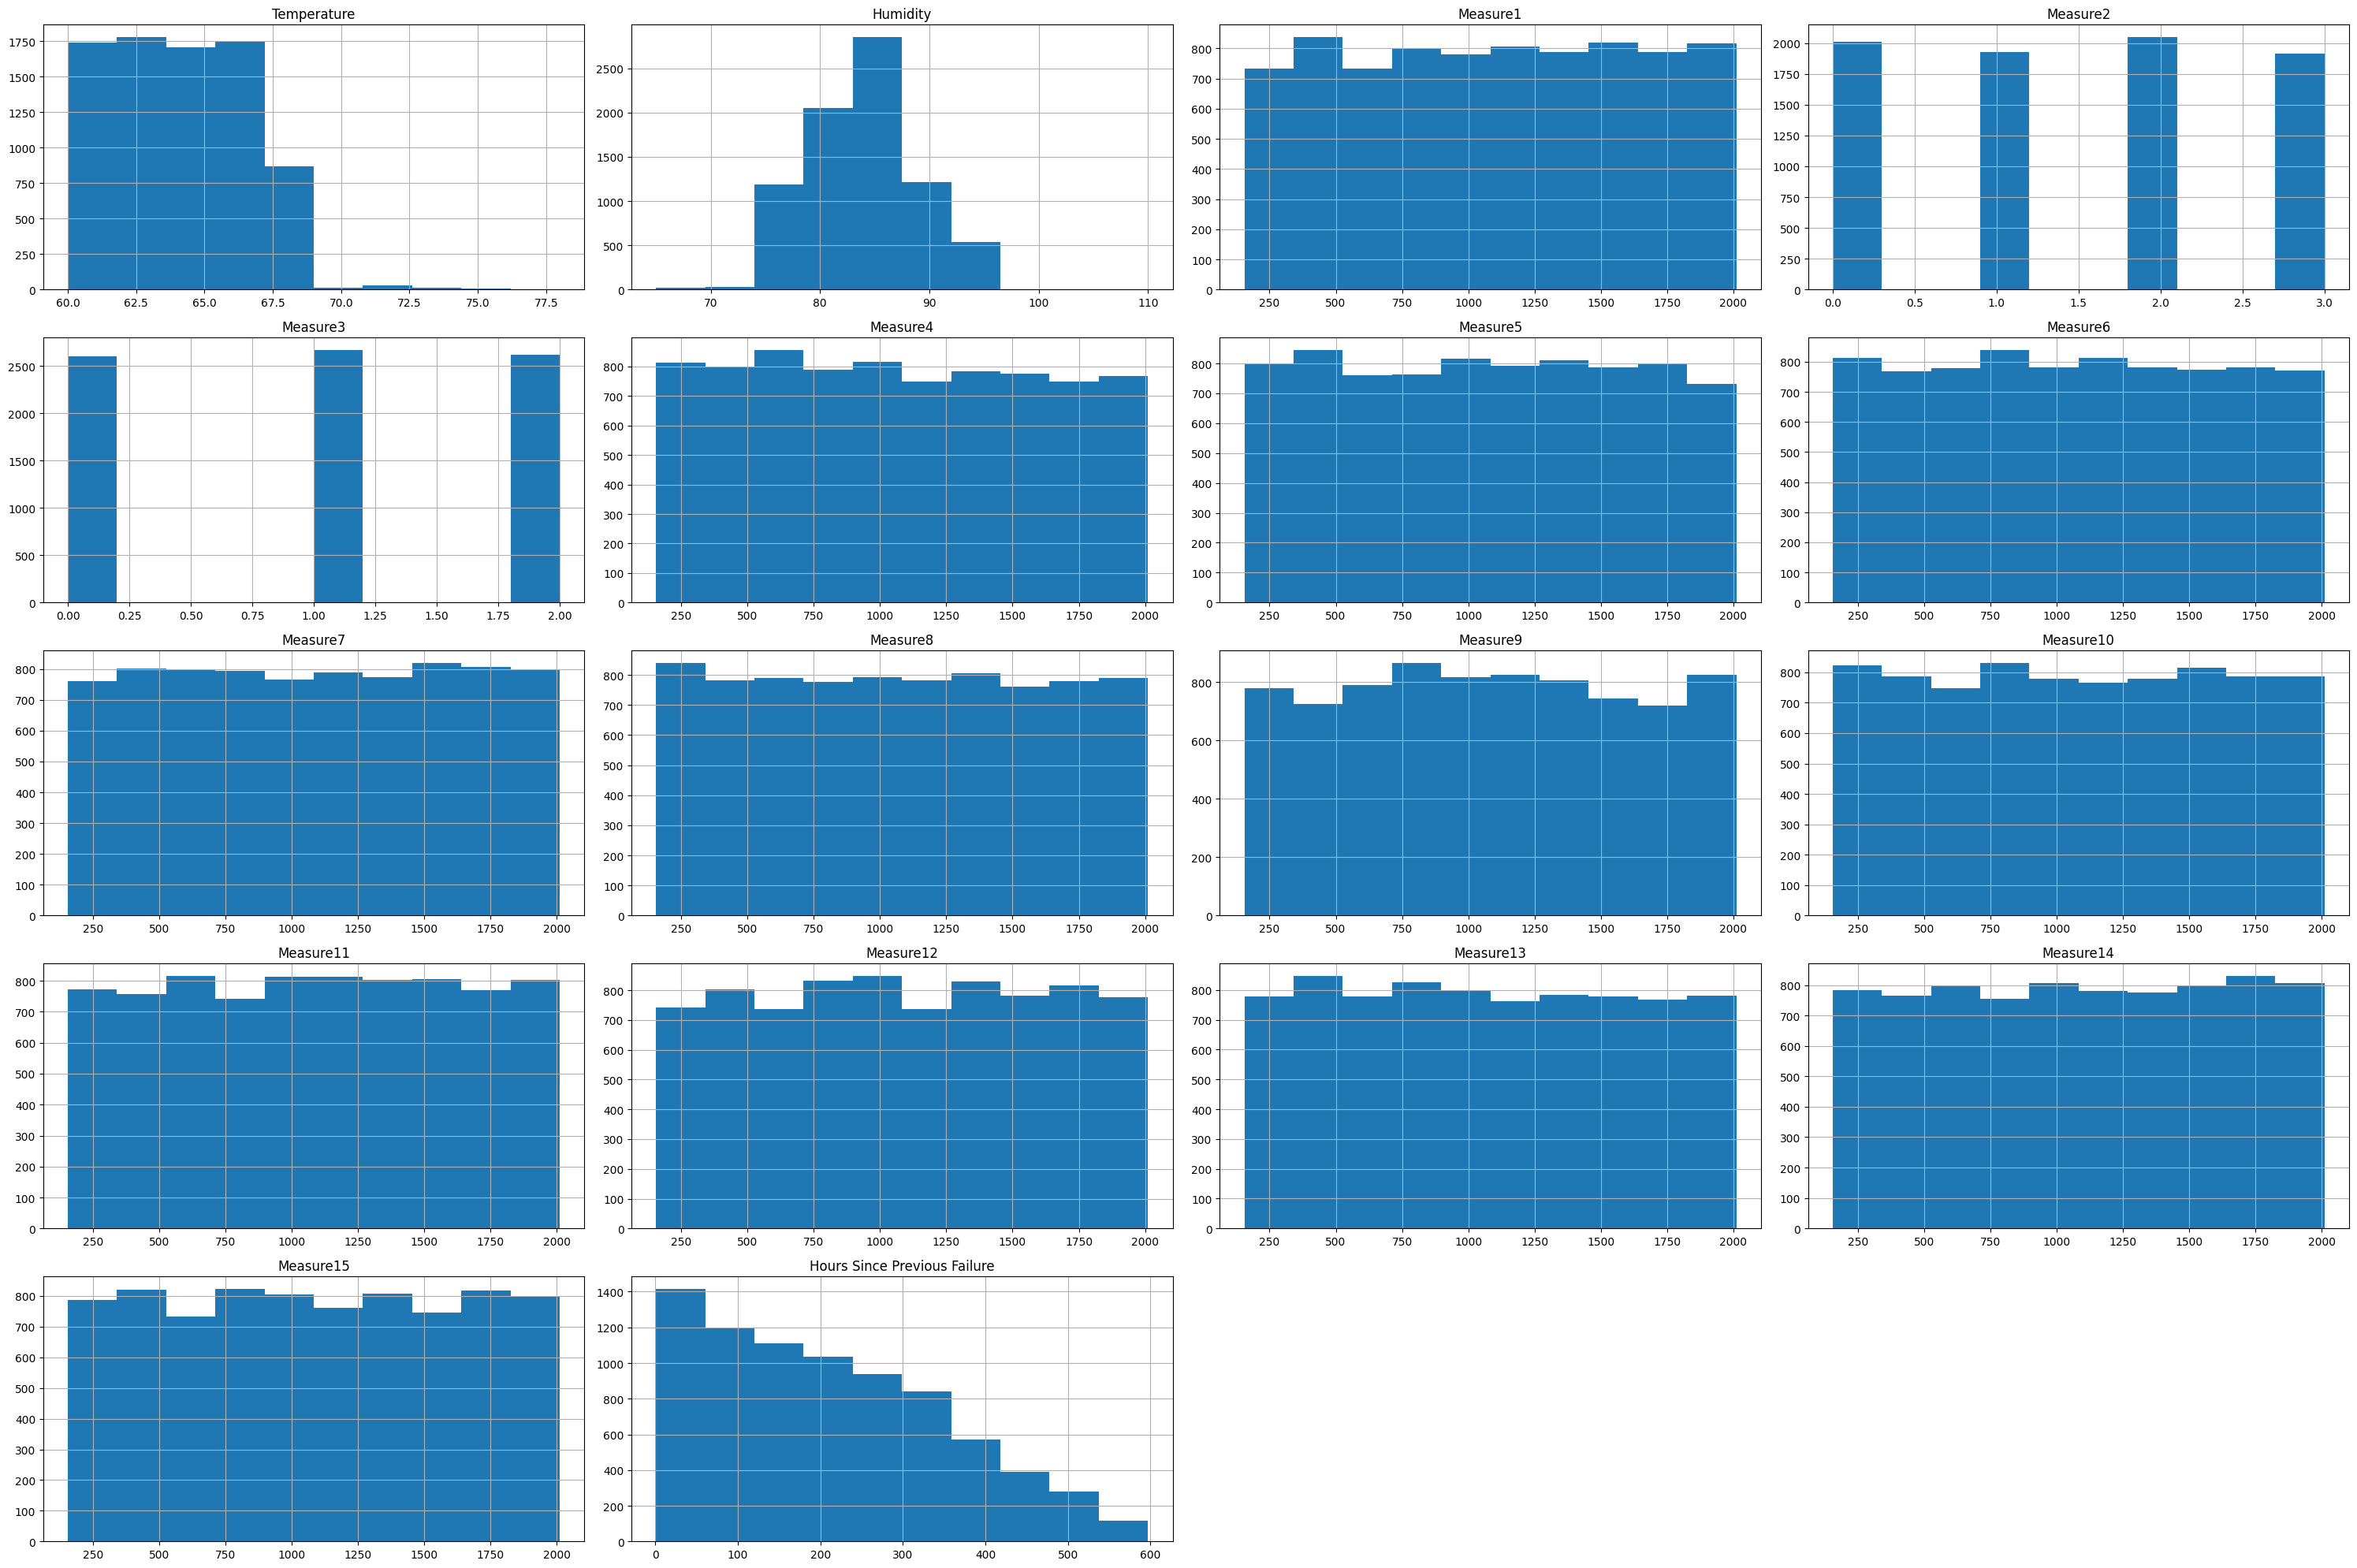

In [7]:
# 히스토그램
MF_Data.hist(figsize=(30, 20))
plt.tight_layout()
plt.show()

> Measure2와 Measure3은 값이 소수의 정수값만 가지므로 **범주형 변수**로 처리해야 함

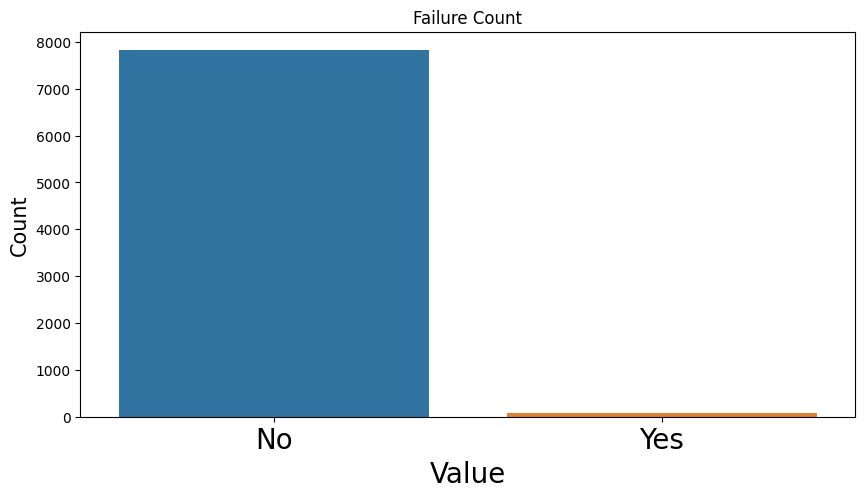

In [8]:
plt.figure(figsize=(10,5))
plt.title("Failure Count")

counts = MF_Data["Failure"].value_counts()

sns.barplot(x=counts.index,
            y=counts.values,
            hue=counts.index)

plt.xticks(fontsize=20)
plt.xlabel("Value",fontsize=20)
plt.ylabel("Count",fontsize=15)
plt.show()

### 1-4) 입출력 변수 분할

In [9]:
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

### 1-5) 범주형 변수 처리 (One-Hot Encoding)

> **One-Hot Encoding**은 범주형 변수의 각 항목을 0과 1로 표현하는 방법임
> - 범주가 k개인 변수를 k개의 새로운 이진 변수로 변환함
> - `pd.get_dummies()`를 사용하면 범주형 변수를 자동으로 One-Hot Encoding 할 수 있음

In [10]:
# Measure2, Measure3을 범주형으로 변환
print("Measure2 고유값:", X["Measure2"].unique())
print("Measure3 고유값:", X["Measure3"].unique())

X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")

Measure2 고유값: [1 0 2 3]
Measure3 고유값: [1 2 0]


In [11]:
# One-Hot Encoding 적용
X = pd.get_dummies(X)
data_columns = X.columns

X.head()

,Temperature,Humidity,Measure1,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,...,Operator_Operator6,Operator_Operator7,Operator_Operator8,Measure2_0,Measure2_1,Measure2_2,Measure2_3,Measure3_0,Measure3_1,Measure3_2
0,67,82,291,1041,846,334,706,1086,256,1295,...,False,False,False,False,True,False,False,False,True,False
1,68,77,1180,1915,1194,637,1093,524,919,245,...,False,False,False,False,True,False,False,False,True,False
2,64,76,1406,511,1577,1121,1948,1882,1301,273,...,False,False,False,False,True,False,False,False,True,False
3,63,80,550,1754,1834,1413,1151,945,1312,1494,...,False,False,False,False,True,False,False,False,True,False
4,65,81,1928,1326,1082,233,1441,1736,1033,1549,...,False,False,False,False,True,False,False,False,False,True


### 1-6) 출력변수 확인

> 불량(Yes) 비율이 약 0.9%로 **매우 불균형한 데이터**임

In [12]:
# 클래스 비율 확인
print(Y.value_counts())
print()
print(Y.value_counts(normalize=True))

Failure
No     7825
Yes      75
Name: count, dtype: int64

Failure
No     0.990506
Yes    0.009494
Name: proportion, dtype: float64


In [13]:
# 출력변수 값 변경 (No -> 0, Yes -> 1)
Y = Y.replace({"No": 0, "Yes": 1}).infer_objects(copy=False)
Y.value_counts()

C:\Users\Admin\AppData\Local\Temp\ipykernel_16768\2680182726.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({"No": 0, "Yes": 1}).infer_objects(copy=False)


Failure
0    7825
1      75
Name: count, dtype: int64

### 1-7) 학습/테스트 데이터 분할

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)

print("전체 데이터 크기   :", X.shape)
print("학습 데이터 크기   :", X_train.shape)
print("테스트 데이터 크기 :", X_test.shape)

전체 데이터 크기   : (7900, 31)
학습 데이터 크기   : (5530, 31)
테스트 데이터 크기 : (2370, 31)


In [15]:
# 클래스 비율이 유지되는지 확인
print("Y 클래스 비율")
print(np.round(Y.value_counts(normalize=True), 3))
print()
print("Y_train 클래스 비율")
print(np.round(Y_train.value_counts(normalize=True), 3))
print()
print("Y_test 클래스 비율")
print(np.round(Y_test.value_counts(normalize=True), 3))

Y 클래스 비율
Failure
0    0.991
1    0.009
Name: proportion, dtype: float64

Y_train 클래스 비율
Failure
0    0.99
1    0.01
Name: proportion, dtype: float64

Y_test 클래스 비율
Failure
0    0.991
1    0.009
Name: proportion, dtype: float64


### 1-8) 스케일링

> 로지스틱 회귀는 입력변수의 **스케일에 민감**하므로, MinMax 또는 Standard 스케일링을 적용해야함

In [16]:
mc = MinMaxScaler()
X_train = mc.fit_transform(X_train)
X_test = mc.transform(X_test)

---

## 2) 로지스틱 회귀

> **로지스틱 회귀**는 출력변수가 범주형(정상/불량)인 경우에 사용되는 분류 모델임
> - 특정 사건이 발생할 **확률**을 예측하며, 확률이 기준값(보통 0.5) 이상이면 해당 클래스로 분류함
> - 로지스틱 함수: $p(X) = \frac{e^{\hat{\beta}_0 + \hat{\beta}_1 X_1 + \cdots + \hat{\beta}_k X_k}}{1 + e^{\hat{\beta}_0 + \hat{\beta}_1 X_1 + \cdots + \hat{\beta}_k X_k}}$
> - 회귀 계수 $\hat{\beta}_k$가 양수면 $X_k$가 증가할수록 불량 확률이 높아지고, 음수면 낮아짐

In [17]:
# 분류 모형 성능 지표 산출 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % (accuracy_score(real, pred)))
    print("Precision : %.3f" % (precision_score(real, pred)))
    print("Recall    : %.3f" % (recall_score(real, pred)))
    print("F1-score  : %.3f" % (f1_score(real, pred)))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 2-1) 모델 학습

In [18]:
LR_model = LogisticRegression()
LR_model.fit(np.array(X_train), np.array(Y_train))

LogisticRegression()

### 2-2) 회귀 계수 확인

> 로지스틱 회귀에서 회귀 계수의 절대값이 클수록 해당 변수의 **분류 영향력이 큼**.

In [19]:
coef_data = pd.DataFrame({"Variable": data_columns, "Coef": np.abs(LR_model.coef_[0])})
coef_data.sort_values(by="Coef", ascending=False)

,Variable,Coef
0,Temperature,6.475519
1,Humidity,5.671526
15,Hours Since Previous Failure,1.891511
23,Operator_Operator8,0.814493
10,Measure11,0.699583
9,Measure10,0.626409
7,Measure8,0.538488
2,Measure1,0.537912
8,Measure9,0.390579
25,Measure2_1,0.349988


### 2-3) 성능 평가

> 분류 모델의 주요 성능 지표:
> - **Accuracy (정확도)**: 전체 중 올바르게 분류한 비율
> - **Precision (정밀도)**: 불량으로 예측한 것 중 실제 불량의 비율
> - **Recall (재현율)**: 실제 불량 중 불량으로 예측한 비율
> - **F1-score**: Precision과 Recall의 조화 평균

In [20]:
LR_predict = LR_model.predict(X_test)
get_classscore(Y_test, LR_predict)

Accuracy  : 0.992
Precision : 1.000
Recall    : 0.136
F1-score  : 0.240

혼동행렬
[[2348    0]
 [  19    3]]


### 2-4) 확률 예측

> `predict_proba()`를 사용하면 각 클래스에 속할 **확률값**을 확인할 수 있음

In [21]:
# 테스트 데이터에 대한 사건 발생 확률 예측
LR_predict_proba = LR_model.predict_proba(X_test)
LR_predict_proba[:5]

array([[0.98980409, 0.01019591],
       [0.98435763, 0.01564237],
       [0.99840493, 0.00159507],
       [0.99861951, 0.00138049],
       [0.99230269, 0.00769731]])

---

## 3) Vibe Coding 실습

### 3-1) 전처리 심화

**[과제 1]** 지수는 불량(Failure) 비율이 약 0.9%에 불과하다는 점을 확인했습니다. 이처럼 클래스 불균형이 심한 데이터에서는 전처리, 로지스틱 회귀 모델 학습, 평가 방법, 고도화 등을 어떻게 설정해야 하는지가 중요합니다. AI와 함께 이를 해결할 수 있는 방법을 찾아보고, 실제로 적용하여 모델 성능이 얼마나 개선되는지 확인해 보세요.

In [22]:
# [과제 1] 클래스 불균형 대응: class_weight / 샘플링 기법 적용
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 1) 클래스 불균형 확인
print("전체 Failure 비율:")
print(Y.value_counts(normalize=True).round(4))

# 2) 기존 모델(불균형 미반영) 성능 확인
print("\n[기존] LogisticRegression (class_weight 미설정)")
get_classscore(Y_test, LR_predict)
print("AUC:", roc_auc_score(Y_test, LR_model.predict_proba(X_test)[:, 1]))

# 3) class_weight='balanced' 적용: 소수 클래스에 더 큰 가중치 부여
LR_balanced = LogisticRegression(class_weight="balanced")
LR_balanced.fit(np.array(X_train), np.array(Y_train))
LR_balanced_pred = LR_balanced.predict(X_test)

print("\n[class_weight='balanced']")
get_classscore(Y_test, LR_balanced_pred)
print("AUC:", roc_auc_score(Y_test, LR_balanced.predict_proba(X_test)[:, 1]))

# 4) Oversampling(SMOTE): 소수 클래스(불량) 샘플을 인위적으로 늘림
smote = SMOTE(random_state=0)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

LR_smote = LogisticRegression()
LR_smote.fit(X_train_smote, Y_train_smote)
LR_smote_pred = LR_smote.predict(X_test)

print("\n[SMOTE Oversampling]")
get_classscore(Y_test, LR_smote_pred)
print("AUC:", roc_auc_score(Y_test, LR_smote.predict_proba(X_test)[:, 1]))

# 5) Undersampling: 다수 클래스(정상) 샘플을 줄임
rus = RandomUnderSampler(random_state=0)
X_train_under, Y_train_under = rus.fit_resample(X_train, Y_train)

LR_under = LogisticRegression()
LR_under.fit(X_train_under, Y_train_under)
LR_under_pred = LR_under.predict(X_test)

print("\n[RandomUnderSampler]")
get_classscore(Y_test, LR_under_pred)
print("AUC:", roc_auc_score(Y_test, LR_under.predict_proba(X_test)[:, 1]))

# 분석: Accuracy만 보면 기존 모델이 가장 높아 보이지만,
#       Recall/F1 관점에서는 class_weight 또는 샘플링 기법 적용이 더 나음
#       -> 불량 탐지가 목표라면 Accuracy보다 Recall, Precision, F1, AUC를 함께 봐야 함


전체 Failure 비율:
Failure
0    0.9905
1    0.0095
Name: proportion, dtype: float64

[기존] LogisticRegression (class_weight 미설정)
Accuracy  : 0.992
Precision : 1.000
Recall    : 0.136
F1-score  : 0.240

혼동행렬
[[2348    0]
 [  19    3]]
AUC: 0.9027605699241134

[class_weight='balanced']
Accuracy  : 0.907
Precision : 0.077
Recall    : 0.818
F1-score  : 0.140

혼동행렬
[[2131  217]
 [   4   18]]
AUC: 0.8921132104692582


c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



[SMOTE Oversampling]
Accuracy  : 0.935
Precision : 0.102
Recall    : 0.773
F1-score  : 0.181

혼동행렬
[[2199  149]
 [   5   17]]
AUC: 0.891145268700635

[RandomUnderSampler]
Accuracy  : 0.830
Precision : 0.043
Recall    : 0.818
F1-score  : 0.082

혼동행렬
[[1949  399]
 [   4   18]]
AUC: 0.8849504413814464


c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


### 3-2) 모델링 및 고도화 심화

**[과제 2]** 지수는 predict_proba로 얻은 불량 확률을 그냥 0.5 기준으로 나누는 게 이 데이터에 적합한지 의문이 듭니다. 임계값(threshold)을 바꿔가며 Precision과 Recall이 어떻게 trade-off 되는지 살펴보는 방법을 AI와 논의하고, 이 데이터에 더 적합한 임계값을 찾아 적용해 보세요.

Threshold별 성능 비교:
   Threshold  Precision  Recall     F1
0        0.1      0.018   0.864  0.036
1        0.2      0.027   0.818  0.052
2        0.3      0.039   0.818  0.074
3        0.4      0.053   0.818  0.099
4        0.5      0.077   0.818  0.140
5        0.6      0.106   0.773  0.187
6        0.7      0.168   0.773  0.276
7        0.8      0.291   0.727  0.416
8        0.9      0.696   0.727  0.711

최적 임계값 (F1 기준): 0.9

[기본 임계값 0.5]
Accuracy  : 0.907
Precision : 0.077
Recall    : 0.818
F1-score  : 0.140

혼동행렬
[[2131  217]
 [   4   18]]

[최적 임계값 0.9]
Accuracy  : 0.995
Precision : 0.696
Recall    : 0.727
F1-score  : 0.711

혼동행렬
[[2341    7]
 [   6   16]]


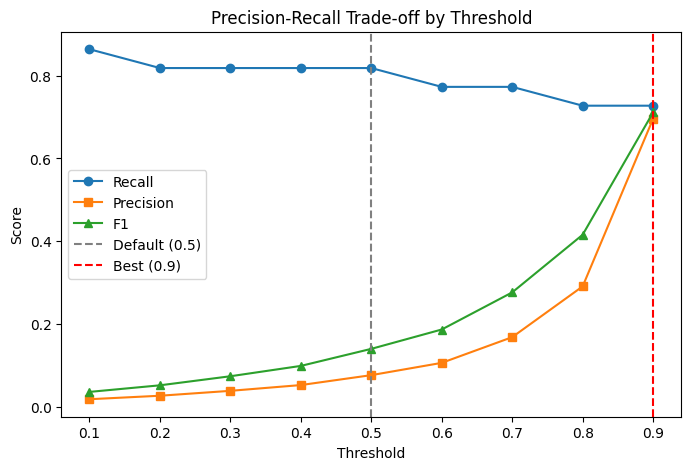

In [23]:
# [과제 2] 임계값(threshold) 조정: Precision-Recall trade-off
from sklearn.metrics import roc_auc_score

# class_weight='balanced' 모델 사용 (불량 탐지에 더 적합)
proba = LR_balanced.predict_proba(X_test)[:, 1]

# 1) 여러 임계값에서 Precision, Recall, F1 비교
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

for th in thresholds:
    pred_th = (proba >= th).astype(int)
    threshold_results.append({
        "Threshold": th,
        "Precision": precision_score(Y_test, pred_th, zero_division=0),
        "Recall": recall_score(Y_test, pred_th),
        "F1": f1_score(Y_test, pred_th),
    })

threshold_df = pd.DataFrame(threshold_results)
print("Threshold별 성능 비교:")
print(threshold_df.round(3))

# 2) F1이 가장 높은 임계값 선택
best_th = threshold_df.loc[threshold_df["F1"].idxmax(), "Threshold"]
print(f"\n최적 임계값 (F1 기준): {best_th}")

# 3) 기본 임계값(0.5) vs 최적 임계값 비교
pred_default = (proba >= 0.5).astype(int)
pred_best = (proba >= best_th).astype(int)

print("\n[기본 임계값 0.5]")
get_classscore(Y_test, pred_default)

print(f"\n[최적 임계값 {best_th}]")
get_classscore(Y_test, pred_best)

# 4) Precision-Recall trade-off 시각화
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="s", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="^", label="F1")
plt.axvline(x=0.5, color="gray", linestyle="--", label="Default (0.5)")
plt.axvline(x=best_th, color="red", linestyle="--", label=f"Best ({best_th})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Threshold")
plt.legend()
plt.show()

# 분석: 임계값을 낮추면 Recall은 올라가고 Precision은 내려감 (trade-off)
#       불량 탐지가 중요한 상황에서는 F1이 가장 높은 임계값을 선택하는 것이 합리적


**[과제 3]** 지수는 선형 회귀에서 Ridge·Lasso를 활용해 모델의 복잡도를 조절할 수 있다는 것을 배웠습니다. 이에 따라 로지스틱 회귀도 과적합을 방지하거나 모델의 복잡도를 조절할 수 있는 방법이 있는지 궁금해졌습니다. AI와 함께 모델 복잡도를 조절하는 기법을 찾아보고, 다양한 설정을 적용하여 성능과 회귀 계수의 변화를 비교해 보세요.

In [24]:
# [과제 3] 로지스틱 회귀 복잡도 조절: penalty(L1/L2)와 C(규제 강도)
from sklearn.linear_model import LogisticRegression

# C 후보: 작을수록 규제 강함, 클수록 규제 약함 (alpha의 역수 개념)
C_values = [0.01, 0.1, 1, 10, 100]

# 1) L2 규제 (Ridge와 유사): 계수를 0에 가깝게 축소
print("=== L2 규제 (penalty='l2') ===")
for C in C_values:
    model = LogisticRegression(penalty="l2", C=C, class_weight="balanced", max_iter=1000)
    model.fit(np.array(X_train), np.array(Y_train))
    pred = model.predict(X_test)
    print(f"C={C:>6} | Recall: {recall_score(Y_test, pred):.3f} | F1: {f1_score(Y_test, pred):.3f} | Non-zero coef: {(model.coef_ != 0).sum()}")

# 2) L1 규제 (Lasso와 유사): 일부 계수를 정확히 0으로 만듦 (변수 선택 효과)
print("\n=== L1 규제 (penalty='l1', solver='saga') ===")
for C in C_values:
    model = LogisticRegression(penalty="l1", C=C, solver="saga", class_weight="balanced", max_iter=1000)
    model.fit(np.array(X_train), np.array(Y_train))
    pred = model.predict(X_test)
    print(f"C={C:>6} | Recall: {recall_score(Y_test, pred):.3f} | F1: {f1_score(Y_test, pred):.3f} | Non-zero coef: {(model.coef_ != 0).sum()}")

# 3) L1 vs L2 회귀 계수 비교 (C=1 기준)
LR_l2 = LogisticRegression(penalty="l2", C=1, class_weight="balanced", max_iter=1000)
LR_l2.fit(np.array(X_train), np.array(Y_train))

LR_l1 = LogisticRegression(penalty="l1", C=1, solver="saga", class_weight="balanced", max_iter=1000)
LR_l1.fit(np.array(X_train), np.array(Y_train))

coef_compare = pd.DataFrame({
    "Variable": data_columns,
    "L2_coef": LR_l2.coef_[0],
    "L1_coef": LR_l1.coef_[0],
})
coef_compare["L1_is_zero"] = coef_compare["L1_coef"] == 0
print("\n회귀 계수 비교 (C=1):")
print(coef_compare.sort_values("L2_coef", key=abs, ascending=False).head(10))
print(f"\nL1에서 0이 된 변수 개수: {coef_compare['L1_is_zero'].sum()} / {len(coef_compare)}")

# 분석: C가 작아질수록 규제가 강해져 계수가 축소됨
#       L1은 일부 변수의 계수를 0으로 만들어 변수 선택 효과가 있음
#       L2는 모든 변수를 유지하되 계수 크기만 줄임


=== L2 규제 (penalty='l2') ===
C=  0.01 | Recall: 0.773 | F1: 0.139 | Non-zero coef: 31
C=   0.1 | Recall: 0.818 | F1: 0.152 | Non-zero coef: 31


C=     1 | Recall: 0.818 | F1: 0.140 | Non-zero coef: 31
C=    10 | Recall: 0.818 | F1: 0.133 | Non-zero coef: 31
C=   100 | Recall: 0.818 | F1: 0.133 | Non-zero coef: 31

=== L1 규제 (penalty='l1', solver='saga') ===


c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=  0.01 | Recall: 0.682 | F1: 0.088 | Non-zero coef: 31


c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

C=    10 | Recall: 0.818 | F1: 0.073 | Non-zero coef: 31


c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=   100 | Recall: 0.864 | F1: 0.049 | Non-zero coef: 31



회귀 계수 비교 (C=1):
                        Variable    L2_coef     L1_coef  L1_is_zero
1                       Humidity -10.517377 -124.350906       False
0                    Temperature   7.397680   75.150031       False
9                      Measure10   1.704447   19.497852       False
15  Hours Since Previous Failure  -1.066384    0.272454       False
21            Operator_Operator6  -0.992580  -10.629331       False
10                     Measure11  -0.716958  -18.880152       False
18            Operator_Operator3   0.706795    5.738151       False
24                    Measure2_0  -0.674067  -11.664069       False
7                       Measure8   0.668253    3.937981       False
8                       Measure9  -0.535458    4.208262       False

L1에서 0이 된 변수 개수: 0 / 31


c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


**[과제 4]** 지수는 모델이 구체적으로 어떤 케이스에서 틀리는지 직접 눈으로 확인하고 싶습니다. 모델이 잘못 예측한 데이터를 추려내는 방법을 AI와 상의해서 추출하고, 이 데이터들이 다른 데이터와 어떤 특징 차이를 보이는지 살펴보세요.

C:\Users\Admin\AppData\Local\Temp\ipykernel_16768\723967083.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_16768\723967083.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_16768\723967083.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_16768\723967083.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

전체 테스트 데이터: 2370건
오분류 데이터: 13건
정분류 데이터: 2357건
  FP (정상을 불량으로 오판): 7건
  FN (불량을 정상으로 오판): 6건

오분류 데이터 (앞 5건):
      Y_true  Y_pred
182        0       1
244        1       0
263        1       0
290        0       1
1013       1       0

정분류 vs 오분류 평균 비교 (스케일링된 값):
                              Correct_mean  Misclassified_mean   Diff
Temperature                          0.224               0.359  0.135
Humidity                             0.419               0.304 -0.115
Measure1                             0.513               0.505 -0.008
Hours Since Previous Failure         0.351               0.326 -0.026


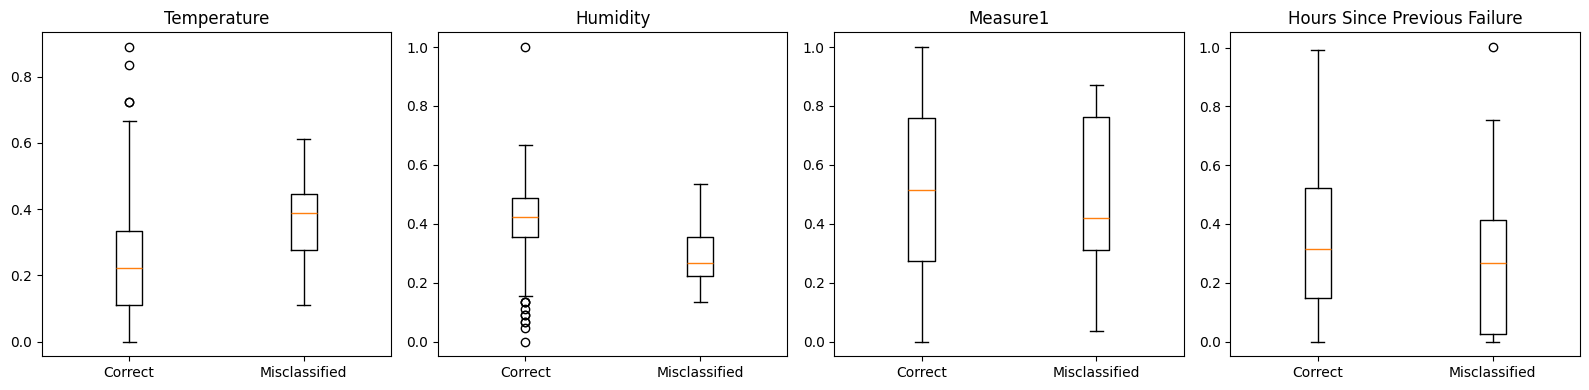

In [25]:
# [과제 4] 오분류 데이터 추출 및 특징 비교

# 1) 테스트 데이터를 DataFrame으로 복원하고 실제값/예측값 추가
X_test_df = pd.DataFrame(X_test, columns=data_columns)
X_test_df["Y_true"] = np.array(Y_test)
X_test_df["Y_pred"] = pred_best

# 2) 오분류 데이터 추출 (Y_true != Y_pred 인 행만 남김)
misclassified = X_test_df[X_test_df["Y_true"] != X_test_df["Y_pred"]]
correct = X_test_df[X_test_df["Y_true"] == X_test_df["Y_pred"]]

print(f"전체 테스트 데이터: {len(X_test_df)}건")
print(f"오분류 데이터: {len(misclassified)}건")
print(f"정분류 데이터: {len(correct)}건")

# 오분류 유형 분류: FP(정상->불량), FN(불량->정상)
fp = misclassified[(misclassified["Y_true"] == 0) & (misclassified["Y_pred"] == 1)]
fn = misclassified[(misclassified["Y_true"] == 1) & (misclassified["Y_pred"] == 0)]
print(f"  FP (정상을 불량으로 오판): {len(fp)}건")
print(f"  FN (불량을 정상으로 오판): {len(fn)}건")

print("\n오분류 데이터 (앞 5건):")
print(misclassified[["Y_true", "Y_pred"]].head())

# 3) 주요 수치형 변수의 평균 비교 (스케일링된 값 기준)
num_cols = ["Temperature", "Humidity", "Measure1", "Hours Since Previous Failure"]

compare_mean = pd.DataFrame({
    "Correct_mean": correct[num_cols].mean(),
    "Misclassified_mean": misclassified[num_cols].mean(),
})
compare_mean["Diff"] = compare_mean["Misclassified_mean"] - compare_mean["Correct_mean"]
print("\n정분류 vs 오분류 평균 비교 (스케일링된 값):")
print(compare_mean.round(3))

# 4) boxplot으로 분포 비교
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(
        [correct[col].values, misclassified[col].values],
        labels=["Correct", "Misclassified"],
    )
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# 분석: 오분류 데이터가 정분류와 비교해 특정 변수에서 평균 차이를 보이는지 확인
#       FP/FN 유형별로 어떤 오류가 더 많은지도 함께 해석
